In [1]:
from chronos import ChronosPipeline

/opt/anaconda3/envs/ml_chronos/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/opt/anaconda3/envs/ml_chronos/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_32035/2438504353.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_32035/2438504353.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_M = df.resample("M")["y"].mean().reset_index()



=== CHRONOS – OFF‑shore TEST METRICS ===
Monthly  MSE=414,959,298,922.56  RMSE=644,173.35  MAE=549,736.06  R²=-1.1060  MAPE=31.47%
Weekly   MSE=484,726,855,014.21  RMSE=696,223.28  MAE=576,909.04  R²=0.0350  MAPE=42.03%


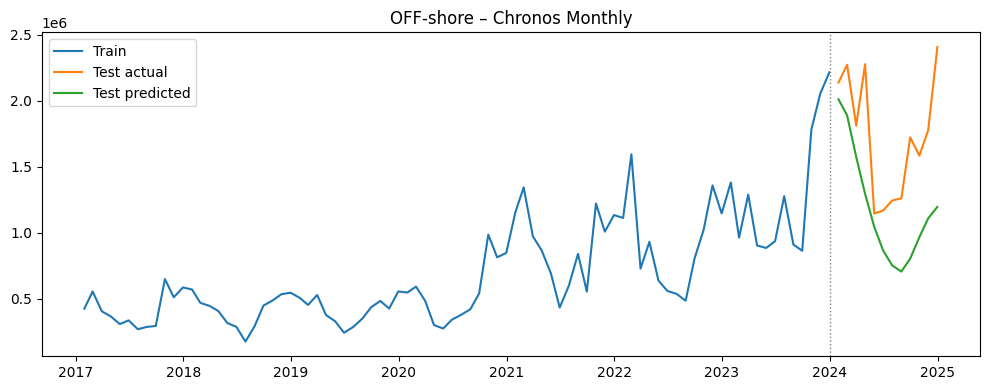

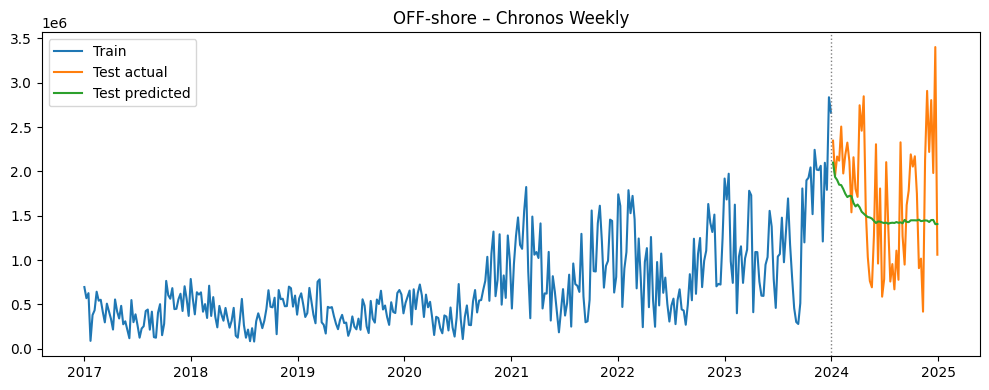

In [ ]:
# ================================================================
#  CHRONOS  –  Monthly / Weekly
# ================================================================
import pandas as pd, numpy as np, torch, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from chronos import ChronosPipeline

DATA_PATH = "data/final_offshore_data_2017_2025.csv"
SITE      = "OFF‑shore"

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"] = df["hour_str"].astype(int) - 1
df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]    = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATES --------------------------------------------------------
df_M = df.resample("M")["y"].mean().reset_index()
df_W = df.resample("W")["y"].mean().reset_index()

# splits
m_tr = df_M[df_M.ds <  "2024-01-01"]; m_te = df_M[(df_M.ds >= "2024-01-01") & (df_M.ds < "2025-01-01")]
w_tr = df_W[df_W.ds <  "2024-01-01"]; w_te = df_W[(df_W.ds >= "2024-01-01") & (df_W.ds < "2025-01-01")]

# 3) Chronos pipeline --------------------------------------------------
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map="cpu", torch_dtype=torch.float32)

def chronos_fc(series, horizon):
    ctx = torch.tensor(series, dtype=torch.float32)
    _, mp = pipeline.predict_quantiles(ctx, horizon, [0.5], limit_prediction_length=False)
    preds = mp[0]
    return preds.detach().cpu().numpy() if preds.ndim==1 else preds.mean(dim=0).detach().cpu().numpy()

# MONTHLY
fc_M = chronos_fc(m_tr["y"].values, len(m_te))
mseM  = mean_squared_error(m_te["y"], fc_M); rmseM=np.sqrt(mseM)
maeM  = mean_absolute_error(m_te["y"], fc_M)
r2M   = r2_score(m_te["y"], fc_M)
mapeM = np.mean(np.abs((m_te["y"]-fc_M)/(m_te["y"]+1e-9)))*100

# WEEKLY
fc_W = chronos_fc(w_tr["y"].values, len(w_te))
mseW  = mean_squared_error(w_te["y"], fc_W); rmseW=np.sqrt(mseW)
maeW  = mean_absolute_error(w_te["y"], fc_W)
r2W   = r2_score(w_te["y"], fc_W)
mapeW = np.mean(np.abs((w_te["y"]-fc_W)/(w_te["y"]+1e-9)))*100

print("\n=== CHRONOS –",SITE,"TEST METRICS ===")
print(f"Monthly  MSE={mseM:,.2f}  RMSE={rmseM:,.2f}  MAE={maeM:,.2f}  R²={r2M:.4f}  MAPE={mapeM:,.2f}%")
print(f"Weekly   MSE={mseW:,.2f}  RMSE={rmseW:,.2f}  MAE={maeW:,.2f}  R²={r2W:.4f}  MAPE={mapeW:,.2f}%")

# 4) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(te["ds"], fc,      label="Test predicted")
    plt.axvline(pd.to_datetime("2024-01-01"), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te, fc_M, f"{SITE} – Chronos Monthly")
plot_one(w_tr, w_te, fc_W, f"{SITE} – Chronos Weekly")
# ================================================================


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_32035/1254632510.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_32035/1254632510.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_M = df.resample("M")["y"].mean().reset_index()



=== CHRONOS – ON‑shore TEST METRICS ===
Monthly  MSE=220,845,624,997.91  RMSE=469,942.15  MAE=381,188.82  R²=0.0453  MAPE=19.05%
Weekly   MSE=563,649,428,540.52  RMSE=750,765.89  MAE=614,483.67  R²=0.0568  MAPE=38.72%


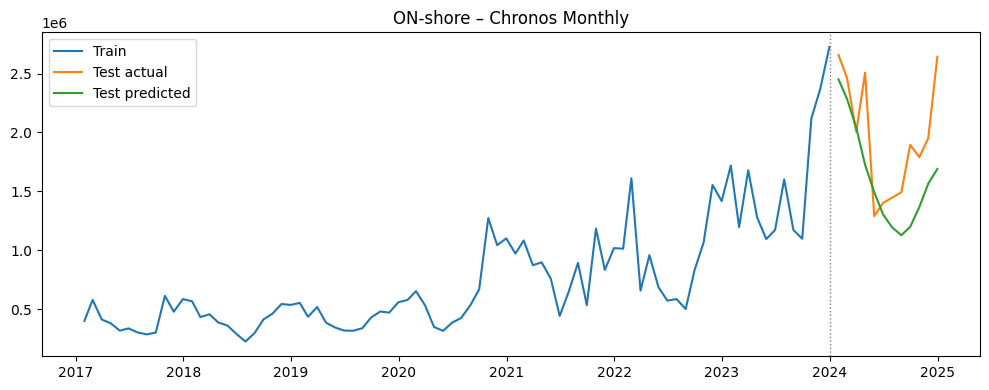

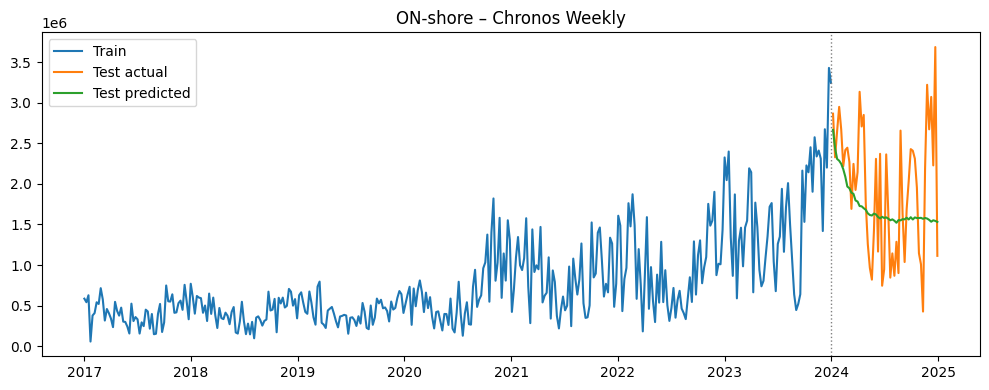

In [ ]:
# ================================================================
#  CHRONOS  –  Monthly / Weekly
# ================================================================
import pandas as pd, numpy as np, torch, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from chronos import ChronosPipeline

DATA_PATH = "data/final_onshore_data_2017_2025.csv" 
SITE      = "ON‑shore"

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"] = df["hour_str"].astype(int) - 1
df["ds"]   = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]    = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATES --------------------------------------------------------
df_M = df.resample("M")["y"].mean().reset_index()
df_W = df.resample("W")["y"].mean().reset_index()

# splits
m_tr = df_M[df_M.ds <  "2024-01-01"]; m_te = df_M[(df_M.ds >= "2024-01-01") & (df_M.ds < "2025-01-01")]
w_tr = df_W[df_W.ds <  "2024-01-01"]; w_te = df_W[(df_W.ds >= "2024-01-01") & (df_W.ds < "2025-01-01")]

# 3) Chronos pipeline --------------------------------------------------
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map="cpu", torch_dtype=torch.float32)

def chronos_fc(series, horizon):
    ctx = torch.tensor(series, dtype=torch.float32)
    _, mp = pipeline.predict_quantiles(ctx, horizon, [0.5], limit_prediction_length=False)
    preds = mp[0]
    return preds.detach().cpu().numpy() if preds.ndim==1 else preds.mean(dim=0).detach().cpu().numpy()

# MONTHLY
fc_M = chronos_fc(m_tr["y"].values, len(m_te))
mseM  = mean_squared_error(m_te["y"], fc_M); rmseM=np.sqrt(mseM)
maeM  = mean_absolute_error(m_te["y"], fc_M)
r2M   = r2_score(m_te["y"], fc_M)
mapeM = np.mean(np.abs((m_te["y"]-fc_M)/(m_te["y"]+1e-9)))*100

# WEEKLY
fc_W = chronos_fc(w_tr["y"].values, len(w_te))
mseW  = mean_squared_error(w_te["y"], fc_W); rmseW=np.sqrt(mseW)
maeW  = mean_absolute_error(w_te["y"], fc_W)
r2W   = r2_score(w_te["y"], fc_W)
mapeW = np.mean(np.abs((w_te["y"]-fc_W)/(w_te["y"]+1e-9)))*100

print("\n=== CHRONOS –",SITE,"TEST METRICS ===")
print(f"Monthly  MSE={mseM:,.2f}  RMSE={rmseM:,.2f}  MAE={maeM:,.2f}  R²={r2M:.4f}  MAPE={mapeM:,.2f}%")
print(f"Weekly   MSE={mseW:,.2f}  RMSE={rmseW:,.2f}  MAE={maeW:,.2f}  R²={r2W:.4f}  MAPE={mapeW:,.2f}%")

# 4) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(te["ds"], fc,      label="Test predicted")
    plt.axvline(pd.to_datetime("2024-01-01"), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te, fc_M, f"{SITE} – Chronos Monthly")
plot_one(w_tr, w_te, fc_W, f"{SITE} – Chronos Weekly")
# ================================================================



=== CHRONOS – Onshore ===


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_30646/1751412782.py:69: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_30646/1751412782.py:76: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  g = df.resample(rule)["y"].mean().to_frame()


Monthly  MSE=386,513,265,527.47  RMSE=621,701.91  MAE=564,213.00  R²=-1.4888  MAPE=28.96%
Weekly   MSE=1,239,546,161,050.04  RMSE=1,113,349.07  MAE=947,563.28  R²=-0.4495  MAPE=53.98%


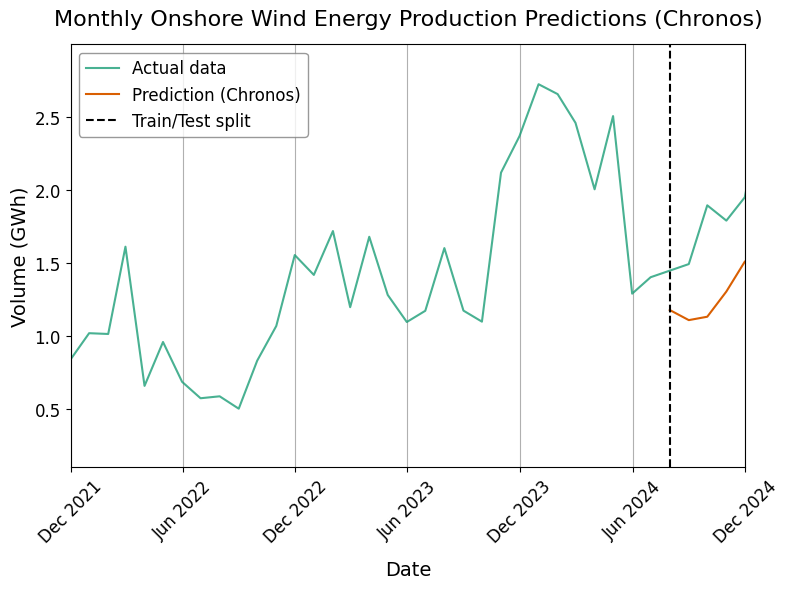

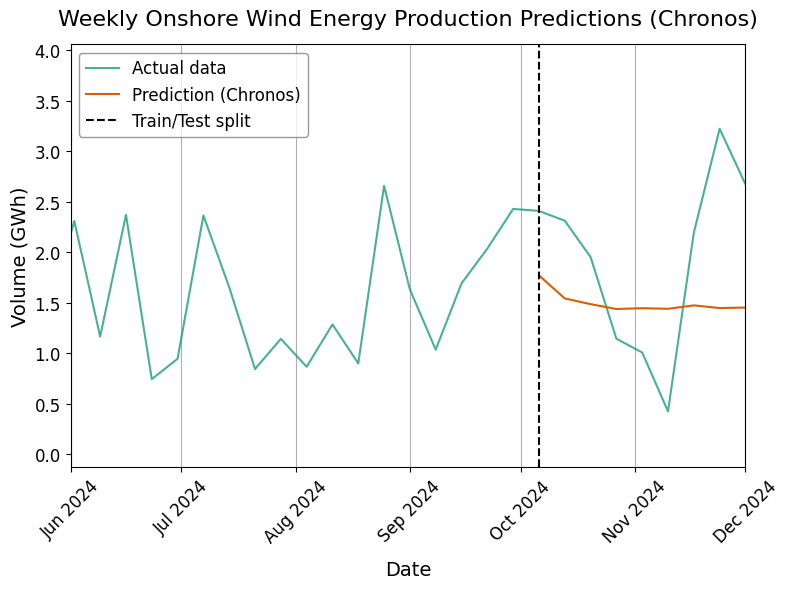


=== CHRONOS – Offshore ===


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_30646/1751412782.py:69: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_30646/1751412782.py:76: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  g = df.resample(rule)["y"].mean().to_frame()


Monthly  MSE=621,844,673,999.47  RMSE=788,571.29  MAE=724,061.53  R²=-3.0810  MAPE=41.61%
Weekly   MSE=1,309,007,239,798.06  RMSE=1,144,118.54  MAE=926,767.90  R²=-0.8837  MAPE=48.21%


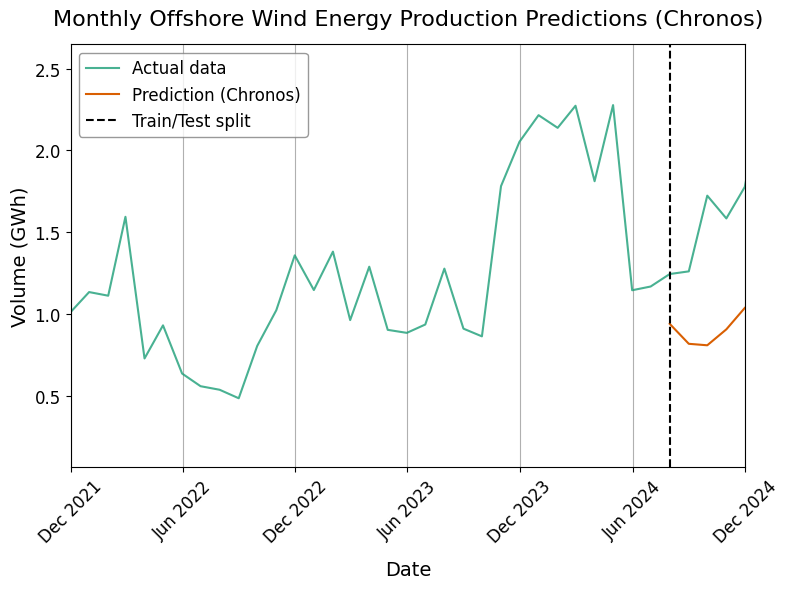

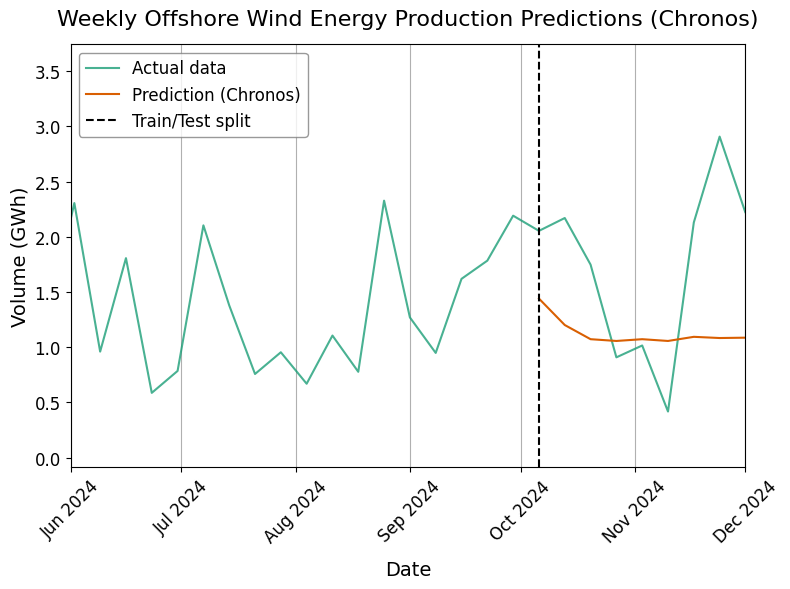

In [ ]:

# -----------------------------------------------------------------------------
# 1. Configuration ------------------------------------------------------------
# -----------------------------------------------------------------------------
DATA_CFG = [
    {
        "path": "data/final_onshore_data_2017_2025.csv",
        "site": "Onshore",
    },
    {
        "path": "data/final_offshore_data_2017_2025.csv",
        "site": "Offshore",
    },
]

# Train / validation / test windows – identical to the Prophet script so that
# plots line up perfectly across models.
SPLITS = {
    "monthly": {
        "train_end": "2024-06-30",
        "val_start": "2024-01-01",
        "val_end": "2024-07-01",
        "test_start": "2024-07-01",
        "test_end": "2025-01-01",
        "xlim": ("2021-12", "2024-12"),
    },
    "weekly": {
        "train_end": "2024-08-31",
        "val_start": "2024-07-01",
        "val_end": "2024-10-01",
        "test_start": "2024-10-01",
        "test_end": "2025-01-01",
        "xlim": ("2024-06", "2024-12"),
    },
}

# Folder where plots will be saved
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# -----------------------------------------------------------------------------
# 2. Helper utilities ----------------------------------------------------------
# -----------------------------------------------------------------------------

def load_hourly_csv(path: str) -> pd.DataFrame:
    """Load the raw hourly CSV and return a time‑indexed DataFrame."""
    df = pd.read_csv(path)
    df[["date", "hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
    df["hour"] = df["hour_str"].astype(int) - 1  # convert 1‑24 → 0‑23
    df["ds"] = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
    df["y"] = df["volume"]
    return df.sort_values("ds").set_index("ds")


def aggregate(df: pd.DataFrame, rule: str) -> pd.DataFrame:
    """Resample by `rule` ("M" or "W") and return tidy frame."""
    g = df.resample(rule)["y"].mean().to_frame()
    g["ds"] = g.index
    return g.reset_index(drop=True)


def split(df: pd.DataFrame, cfg: dict):
    """Return train / validation / test slices using date boundaries from cfg."""
    tr = df[df.ds <= cfg["train_end"]].copy()
    val = df[(df.ds >= cfg["val_start"]) & (df.ds < cfg["val_end"])].copy()
    te = df[(df.ds >= cfg["test_start"]) & (df.ds < cfg["test_end"])].copy()
    return tr, val, te


def chronos_forecast(pipeline: ChronosPipeline, series: np.ndarray, horizon: int) -> np.ndarray:
    """Wrapper around Chronos `predict_quantiles` – returns the mean forecast."""
    ctx = torch.tensor(series, dtype=torch.float32)
    _, med = pipeline.predict_quantiles(ctx, horizon, [0.5], limit_prediction_length=False)
    preds = med[0]  # shape: (horizon,)
    if preds.ndim > 1:  # safety – shouldn’t happen with 0.5 quantile
        preds = preds.mean(dim=0)
    return preds.detach().cpu().numpy()


def _millions(x, pos):
    """Custom formatter: 2_500_000 → 2.5"""
    return f"{x * 1e-6:.1f}"


def styled_plot(full_df: pd.DataFrame,
                fc_df: pd.DataFrame,
                *,
                freq: str,                      # "Monthly" | "Weekly"
                title: str,
                split_ts: pd.Timestamp,
                xlim_start: str,
                xlim_end: str,
                filename: str | None = None):
    """Draw a timeline that visually matches the Prophet plots."""
    plt.figure(figsize=(8, 6))

    # Actual trajectory (train + val + test)
    plt.plot(full_df["ds"], full_df["y"], label="Actual data",
             color="#1b9e77", alpha=0.8)

    # Chronos forecast (test horizon)
    plt.plot(fc_df["ds"], fc_df["yhat"], label="Prediction (Chronos)",
             color="#d95f02")

    # Train / test split marker
    plt.axvline(split_ts, color="k", linestyle="--", label="Train/Test split")

    # Decorate axes
    plt.title(title, pad=14, fontsize=16)
    plt.xlabel("Date", labelpad=10, fontsize=14)
    plt.ylabel("Volume (GWh)", fontsize=14)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(FuncFormatter(_millions))
    ax.grid(axis="x")
    ax.tick_params(axis="both", labelsize=12)
    plt.xticks(rotation=45)

    # X‑tick granularity
    if freq == "Monthly":
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    else:  # Weekly
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    # Axis limits
    plt.xlim(pd.to_datetime(xlim_start), pd.to_datetime(xlim_end))
    ymax = max(full_df["y"].max(), fc_df["yhat"].max()) * 1.1
    plt.ylim(top=ymax)

    # Legend & layout
    plt.legend(loc="best", fontsize=12, frameon=True,
               facecolor="white", edgecolor="grey", fancybox=True,
               framealpha=0.8)
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# -----------------------------------------------------------------------------
# 3. Main routine for a single site -------------------------------------------
# -----------------------------------------------------------------------------

def run_site(cfg_site: dict, pipeline: ChronosPipeline):
    site = cfg_site["site"]
    print(f"\n=== CHRONOS – {site} ===")

    # ---- 1) Load & aggregate --------------------------------------------
    raw = load_hourly_csv(cfg_site["path"])
    df_M = aggregate(raw, "M")
    df_W = aggregate(raw, "W")

    # ---- 2) Temporal split ---------------------------------------------
    m_tr, m_val, m_te = split(df_M, SPLITS["monthly"])
    w_tr, w_val, w_te = split(df_W, SPLITS["weekly"])

    # ---- 3) Fit / predict ----------------------------------------------
    fc_M_vals = chronos_forecast(pipeline, m_tr["y"].values, len(m_te))
    fc_W_vals = chronos_forecast(pipeline, w_tr["y"].values, len(w_te))

    # Put forecasts into DataFrames for easy handling
    fc_M = pd.DataFrame({"ds": m_te["ds"].values, "yhat": fc_M_vals})
    fc_W = pd.DataFrame({"ds": w_te["ds"].values, "yhat": fc_W_vals})

    # ---- 4) Metrics -----------------------------------------------------
    def _metrics(true, pred):
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(true, pred)
        r2 = r2_score(true, pred)
        mape = np.mean(np.abs((true - pred) / (true + 1e-9))) * 100
        return mse, rmse, mae, r2, mape

    m_metrics = _metrics(m_te["y"].values, fc_M_vals)
    w_metrics = _metrics(w_te["y"].values, fc_W_vals)

    for lbl, m in zip(["Monthly", "Weekly"], [m_metrics, w_metrics]):
        mse, rmse, mae, r2, mape = m
        print(f"{lbl:<7}  MSE={mse:,.2f}  RMSE={rmse:,.2f}  MAE={mae:,.2f}  R²={r2:.4f}  MAPE={mape:,.2f}%")

    # ---- 5) Plots -------------------------------------------------------
    concat = lambda *dfs: pd.concat(dfs).sort_values("ds")

    styled_plot(full_df=concat(m_tr, m_val, m_te),
                fc_df=fc_M,
                freq="Monthly",
                title=f"Monthly {site} Wind Energy Production Predictions (Chronos)",
                split_ts=m_te.ds.min(),
                xlim_start=SPLITS["monthly"]["xlim"][0],
                xlim_end=SPLITS["monthly"]["xlim"][1],
                filename=f"{PLOT_DIR}/{site.lower().replace('-', '')}_chronos_mon.png")

    styled_plot(full_df=concat(w_tr, w_val, w_te),
                fc_df=fc_W,
                freq="Weekly",
                title=f"Weekly {site} Wind Energy Production Predictions (Chronos)",
                split_ts=w_te.ds.min(),
                xlim_start=SPLITS["weekly"]["xlim"][0],
                xlim_end=SPLITS["weekly"]["xlim"][1],
                filename=f"{PLOT_DIR}/{site.lower().replace('-', '')}_chronos_week.png")

# -----------------------------------------------------------------------------
# 4. Entry point --------------------------------------------------------------
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    # Load the Chronos‑T5 model once and reuse for both sites
    chronos_pipe = ChronosPipeline.from_pretrained(
        "amazon/chronos-t5-small",
        device_map="cpu",            # change to "auto" for GPU inference if available
        torch_dtype=torch.float32,
    )

    for cfg in DATA_CFG:
        run_site(cfg, chronos_pipe)
